# Collect scalar metrics + loss curves across all runs

Walks every `<dataset>/<size>/<quality>/results/<algo>/` run under `/home/igor/noise_scaling/data` and produces four artifacts in `data/other/csvs/`:

1. **`mi_per_run.csv`** — long table of MI values, one row per (dataset, size, quality, algorithm, signal, seed).
2. **`training_metrics_per_run.csv`** — long table of scalar training metrics (`test_loss`, `train_loss`, `val_loss`, `ridge_mean_*`, `best_val_loss`, `best_step`, `total_steps`, `epoch_max`) per (dataset, size, quality, algorithm). Missing files are simply absent rows (not NaN).
3. **`loss_curves_long.parquet`** — single long-format parquet of per-step train + val loss for every Geneformer/State run: columns `dataset, size, quality, algorithm, phase, step, loss`.
4. **`loss_curves.h5`** — the same data in a hierarchical HDF5: `/<algo>/<dataset>/<size>/<quality>/{train,val}_{step,loss}` plus per-run attrs. Faster for single-run lookup.

Parsers are copied verbatim from `2026-04-18_09-49_plotting_loss_curves_all_algos.ipynb` and `2026-04-14_15-25_collect_and_plot_mi_scaling.ipynb`.

In [1]:
import os
import re
import json
from pathlib import Path
from itertools import product
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import h5py
from tqdm.auto import tqdm

DATA_ROOT = Path('/home/igor/noise_scaling/data')
CSV_DIR = DATA_ROOT / 'other' / 'csvs'
CSV_DIR.mkdir(parents=True, exist_ok=True)

ALGOS = ['Geneformer', 'PCA', 'RandomProjection', 'SCVI', 'State']
ALGOS_WITH_CURVES = ['State', 'Geneformer']  # SCVI logs to wandb; PCA/RP have no training
SEEDS = [42, 1404, 2303, 2701]

EXPECTED = {
    'PBMC': {
        'sizes': [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000],
        'qualities': [0.0012346, 0.0025982, 0.0054682, 0.0115083, 0.02422, 0.050973, 0.1072766, 0.225772, 0.4751547, 1.0],
        'signals': ['celltype.l3', 'protein_counts'],
        'seeds': SEEDS,
    },
    'larry': {
        'sizes': [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000],
        'qualities': [0.003876, 0.0071835, 0.0133136, 0.0246748, 0.0457311, 0.0847557, 0.1570821, 0.2911284, 0.5395631, 1.0],
        'signals': ['clone'],
        'seeds': SEEDS,
    },
    'merfish': {
        'sizes': [100, 203, 414, 843, 1716, 3494, 7113, 14480, 29475, 60000],
        'qualities': [0.027248, 0.0406617, 0.0606789, 0.0905502, 0.1351267, 0.2016475, 0.3009156, 0.4490518, 0.6701133, 1.0],
        'signals': ['cur_idx', 'ng_idx'],
        'seeds': SEEDS,
    },
    'shendure': {
        'sizes': [100, 359, 1291, 4641, 16681, 59948, 215443, 774263, 2782559, 10000000],
        'qualities': [0.004, 0.0073875, 0.0136438, 0.0251984, 0.0465384, 0.0859506, 0.1587401, 0.2931733, 0.5414548, 1.0],
        'signals': ['author_day'],
        'seeds': SEEDS,
    },
}

print(f'Output dir: {CSV_DIR}')

Output dir: /home/igor/noise_scaling/data/other/csvs


/home/igor/miniconda3/envs/modeling/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. MI per run → `mi_per_run.csv`

Build the full cartesian product of expected MI paths, check existence in parallel, read survivors.

In [2]:
def _read_scalar(path):
    try:
        return float(Path(path).read_text().strip())
    except Exception:
        return np.nan

mi_rows = []
for ds, cfg in EXPECTED.items():
    for sz, q, algo, sig, sd in product(cfg['sizes'], cfg['qualities'], ALGOS, cfg['signals'], cfg['seeds']):
        suffix = '_geneformer' if algo == 'Geneformer' else ''
        stem = f'Y_{sig}_{q}{suffix}'
        mi_path = DATA_ROOT / ds / str(sz) / str(q) / 'results' / algo / 'model' / 'MI' / str(sd) / stem / 'lmi_mutual_information.txt'
        mi_rows.append({
            'dataset': ds, 'size': sz, 'quality': q, 'algorithm': algo,
            'signal': sig, 'seed': sd, 'path': str(mi_path),
        })

df_mi_expected = pd.DataFrame(mi_rows)
print(f'Total expected MI files: {len(df_mi_expected):,}')

with ThreadPoolExecutor(max_workers=128) as pool:
    df_mi_expected['exists'] = list(tqdm(
        pool.map(os.path.exists, df_mi_expected['path']),
        total=len(df_mi_expected), desc='Scan MI',
    ))

df_mi = df_mi_expected[df_mi_expected['exists']].copy()
print(f'Found: {len(df_mi):,}  |  Missing: {len(df_mi_expected) - len(df_mi):,}')

with ThreadPoolExecutor(max_workers=128) as pool:
    df_mi['mi_nats'] = list(tqdm(
        pool.map(_read_scalar, df_mi['path']),
        total=len(df_mi), desc='Read MI',
    ))

df_mi = (
    df_mi.dropna(subset=['mi_nats'])
         [['dataset', 'size', 'quality', 'algorithm', 'signal', 'seed', 'mi_nats']]
         .sort_values(['dataset', 'algorithm', 'signal', 'size', 'quality', 'seed'])
         .reset_index(drop=True)
)
out_path = CSV_DIR / 'mi_per_run.csv'
df_mi.to_csv(out_path, index=False)
print(f'Wrote {out_path} — {len(df_mi):,} rows')
df_mi.head()

Total expected MI files: 12,000


Scan MI:   0%|          | 0/12000 [00:00<?, ?it/s]

Scan MI: 100%|██████████| 12000/12000 [00:00<00:00, 499054.55it/s]

Found: 8,519  |  Missing: 3,481


Read MI:   0%|          | 0/8519 [00:00<?, ?it/s]

Read MI:  66%|██████▌   | 5593/8519 [00:00<00:00, 55536.14it/s]

Read MI: 100%|██████████| 8519/8519 [00:00<00:00, 23384.57it/s]

Wrote /home/igor/noise_scaling/data/other/csvs/mi_per_run.csv — 8,519 rows


,dataset,size,quality,algorithm,signal,seed,mi_nats
0,PBMC,100,0.001235,Geneformer,celltype.l3,42,0.40001
1,PBMC,100,0.001235,Geneformer,celltype.l3,1404,0.40144
2,PBMC,100,0.001235,Geneformer,celltype.l3,2303,0.49980
3,PBMC,100,0.001235,Geneformer,celltype.l3,2701,0.35772
4,PBMC,100,0.002598,Geneformer,celltype.l3,42,0.75504


## 2. Loss curves (STATE + Geneformer)

Loaders copied verbatim from `2026-04-18_09-49_plotting_loss_curves_all_algos.ipynb`:

- **State** — `results/State/model/loss/metrics.csv` (Lightning) → columns `step, trainer/train_loss, validation/val_loss`.
- **Geneformer** — highest-numbered `results/Geneformer/checkpoint-NNNN/trainer_state.json`, with `log_history` split on `loss` vs `eval_loss`.
- **SCVI** — no per-step history on disk (wandb only); we still record its `test_loss.txt` in the scalar metrics table below.

Populates a nested dict `curves[algo][dataset][size][quality] = {train, val, best_step, best_val, total_steps, epoch_max}`.

In [3]:
_CKPT_RE = re.compile(r'checkpoint-(\d+)$')

def _is_size_dir(p):
    return p.is_dir() and p.name.isdigit()

def _is_quality_dir(p):
    if not p.is_dir():
        return False
    try:
        float(p.name); return True
    except ValueError:
        return False

def _load_state(model_dir):
    csv = model_dir / 'loss' / 'metrics.csv'
    if not csv.exists():
        ckpt_dir = model_dir / 'checkpoints'
        if ckpt_dir.is_dir():
            matches = list(ckpt_dir.glob('state_*/version_*/metrics.csv'))
            if matches:
                csv = matches[0]
    if not csv.exists():
        return None
    try:
        df = pd.read_csv(csv, on_bad_lines='skip')
    except Exception:
        return None
    needed = {'step', 'trainer/train_loss', 'validation/val_loss'}
    if not needed.issubset(df.columns):
        return None
    train = (df[['step', 'trainer/train_loss']].dropna()
               .rename(columns={'trainer/train_loss': 'loss'})
               .reset_index(drop=True))
    val = (df[['step', 'validation/val_loss']].dropna()
             .rename(columns={'validation/val_loss': 'loss'})
             .reset_index(drop=True))
    if train.empty or val.empty:
        return None
    bidx = val['loss'].idxmin()
    return {
        'train': train, 'val': val,
        'best_step':  int(val.iloc[bidx]['step']),
        'best_val':   float(val.iloc[bidx]['loss']),
        'total_steps': int(df['step'].max()) if 'step' in df.columns else 0,
        'epoch_max':   int(df['epoch'].max()) if 'epoch' in df.columns and df['epoch'].notna().any() else -1,
    }

def _latest_geneformer_trainer_state(gf_root):
    if not gf_root.is_dir():
        return None
    best = None; best_step = -1
    for p in gf_root.iterdir():
        m = _CKPT_RE.search(p.name)
        if m and p.is_dir():
            step = int(m.group(1))
            ts = p / 'trainer_state.json'
            if ts.exists() and step > best_step:
                best_step, best = step, ts
    return best

def _load_geneformer(algo_root):
    ts = _latest_geneformer_trainer_state(algo_root)
    if ts is None:
        return None
    try:
        state = json.loads(ts.read_text())
    except Exception:
        return None
    log = state.get('log_history', []) or []
    train_rows = [(e['step'], e['loss'])      for e in log if 'loss'      in e and 'step' in e]
    val_rows   = [(e['step'], e['eval_loss']) for e in log if 'eval_loss' in e and 'step' in e]
    if not train_rows or not val_rows:
        return None
    train = pd.DataFrame(train_rows, columns=['step', 'loss']).sort_values('step').reset_index(drop=True)
    val   = pd.DataFrame(val_rows,   columns=['step', 'loss']).sort_values('step').reset_index(drop=True)
    best_ckpt = state.get('best_model_checkpoint') or ''
    m = _CKPT_RE.search(best_ckpt or '')
    if m:
        best_step = int(m.group(1))
        hit = val[val['step'] == best_step]
        best_val = float(hit.iloc[0]['loss']) if not hit.empty else float(val['loss'].min())
    else:
        bidx = val['loss'].idxmin()
        best_step = int(val.iloc[bidx]['step']); best_val = float(val.iloc[bidx]['loss'])
    return {
        'train': train, 'val': val,
        'best_step': best_step, 'best_val': best_val,
        'total_steps': int(state.get('global_step') or train['step'].max()),
        'epoch_max':   int(state.get('epoch') or -1),
    }

LOADERS = {
    'State':      lambda qdir: _load_state((qdir / 'results' / 'State' / 'model')),
    'Geneformer': lambda qdir: _load_geneformer((qdir / 'results' / 'Geneformer')),
}

curves = {a: {} for a in ALGOS_WITH_CURVES}
for ds in tqdm(list(EXPECTED.keys()), desc='Datasets'):
    ds_dir = DATA_ROOT / ds
    if not ds_dir.is_dir():
        continue
    size_dirs = sorted(filter(_is_size_dir, ds_dir.iterdir()), key=lambda p: int(p.name))
    for size_dir in tqdm(size_dirs, desc=f'{ds} sizes', leave=False):
        size = int(size_dir.name)
        q_dirs = sorted(filter(_is_quality_dir, size_dir.iterdir()), key=lambda p: float(p.name))
        for q_dir in q_dirs:
            q = float(q_dir.name)
            for algo, fn in LOADERS.items():
                info = fn(q_dir)
                if info is None:
                    continue
                curves[algo].setdefault(ds, {}).setdefault(size, {})[q] = info

for algo in ALGOS_WITH_CURVES:
    n_runs = sum(len(qm) for ds in curves[algo] for qm in curves[algo][ds].values())
    print(f'{algo:>11}: {n_runs:>4} runs loaded')

Datasets:   0%|          | 0/4 [00:00<?, ?it/s]

PBMC sizes:   0%|          | 0/10 [00:00<?, ?it/s]

PBMC sizes:  10%|█         | 1/10 [00:00<00:01,  8.04it/s]

PBMC sizes:  20%|██        | 2/10 [00:00<00:01,  7.60it/s]

PBMC sizes:  30%|███       | 3/10 [00:00<00:00,  7.23it/s]

...

shendure sizes:  80%|████████  | 8/10 [00:01<00:00,  5.27it/s]

shendure sizes: 100%|██████████| 10/10 [00:01<00:00,  6.79it/s]

Datasets: 100%|██████████| 4/4 [00:07<00:00,  1.81s/it]

Datasets: 100%|██████████| 4/4 [00:07<00:00,  1.83s/it]

      State:  377 runs loaded
 Geneformer:  399 runs loaded


### 2a. Long-format parquet → `loss_curves_long.parquet`

Flatten `curves` to a tall DataFrame with `phase ∈ {train, val}`. Good for `df.query("algorithm == 'State' and dataset == 'PBMC'")` style filtering.

In [4]:
long_frames = []
for algo in ALGOS_WITH_CURVES:
    for ds, size_map in curves[algo].items():
        for size, q_map in size_map.items():
            for q, info in q_map.items():
                for phase in ('train', 'val'):
                    df = info.get(phase)
                    if df is None or df.empty:
                        continue
                    long_frames.append(pd.DataFrame({
                        'dataset':   ds,
                        'size':      size,
                        'quality':   q,
                        'algorithm': algo,
                        'phase':     phase,
                        'step':      df['step'].astype('int64').values,
                        'loss':      df['loss'].astype('float64').values,
                    }))

df_curves = pd.concat(long_frames, ignore_index=True) if long_frames else pd.DataFrame(
    columns=['dataset', 'size', 'quality', 'algorithm', 'phase', 'step', 'loss'])
for col in ['dataset', 'algorithm', 'phase']:
    df_curves[col] = df_curves[col].astype('category')

parquet_path = CSV_DIR / 'loss_curves_long.parquet'
df_curves.to_parquet(parquet_path, index=False, compression='zstd')
print(f'Wrote {parquet_path} — {len(df_curves):,} rows ({parquet_path.stat().st_size / 1e6:.1f} MB)')
df_curves.groupby(['algorithm', 'phase'], observed=True).size().to_frame('rows')

Wrote /home/igor/noise_scaling/data/other/csvs/loss_curves_long.parquet — 4,243,577 rows (25.3 MB)


rows
algorithm  phase         
Geneformer train     7935
           val       7935
State      train  4223536
           val       4171

### 2b. Hierarchical HDF5 → `loss_curves.h5`

Group layout: `/<algorithm>/<dataset>/<size>/<quality>/` with datasets `train_step`, `train_loss`, `val_step`, `val_loss` and attrs `best_step`, `best_val`, `total_steps`, `epoch_max`. Lets you pull one run in O(1) without scanning the parquet:

```python
with h5py.File('.../loss_curves.h5', 'r') as f:
    g = f['State/PBMC/10000/1.0']
    train_step = g['train_step'][:]; train_loss = g['train_loss'][:]
```

In [5]:
h5_path = CSV_DIR / 'loss_curves.h5'
n_groups = 0
with h5py.File(h5_path, 'w') as f:
    for algo in ALGOS_WITH_CURVES:
        for ds, size_map in curves[algo].items():
            for size, q_map in size_map.items():
                for q, info in q_map.items():
                    group = f.create_group(f'{algo}/{ds}/{size}/{q}')
                    for phase in ('train', 'val'):
                        df = info.get(phase)
                        if df is None or df.empty:
                            continue
                        group.create_dataset(f'{phase}_step', data=df['step'].to_numpy('int64'),
                                             compression='gzip', compression_opts=4)
                        group.create_dataset(f'{phase}_loss', data=df['loss'].to_numpy('float64'),
                                             compression='gzip', compression_opts=4)
                    for k in ('best_step', 'best_val', 'total_steps', 'epoch_max'):
                        v = info.get(k)
                        if v is None:
                            continue
                        group.attrs[k] = v
                    n_groups += 1
print(f'Wrote {h5_path} — {n_groups:,} run groups ({h5_path.stat().st_size / 1e6:.1f} MB)')

Wrote /home/igor/noise_scaling/data/other/csvs/loss_curves.h5 — 776 run groups (32.0 MB)


## 3. Scalar training metrics → `training_metrics_per_run.csv`

Reads every `.txt` scalar (`test_loss`, `train_loss`, `val_loss`, `ridge_mean_{mae,mse,r2}`) that exists on disk, then merges in derived scalars from the loss-curve dict (`best_val_loss`, `best_step`, `total_steps`, `epoch_max`). Long format: one row per (dataset, size, quality, algorithm, metric) — missing metrics simply absent.

In [6]:
SCALAR_FILES = {
    'test_loss':      'test_loss.txt',
    'train_loss':     'train_loss.txt',
    'val_loss':       'val_loss.txt',
    'ridge_mean_mae': 'ridge_mean_mae.txt',
    'ridge_mean_mse': 'ridge_mean_mse.txt',
    'ridge_mean_r2':  'ridge_mean_r2.txt',
}

expected_scalar = []
for ds, cfg in EXPECTED.items():
    for sz, q, algo, metric in product(cfg['sizes'], cfg['qualities'], ALGOS, SCALAR_FILES):
        path = DATA_ROOT / ds / str(sz) / str(q) / 'results' / algo / 'model' / SCALAR_FILES[metric]
        expected_scalar.append({
            'dataset': ds, 'size': sz, 'quality': q, 'algorithm': algo,
            'metric': metric, 'path': str(path),
        })

df_sc = pd.DataFrame(expected_scalar)
print(f'Total expected scalar files: {len(df_sc):,}')

with ThreadPoolExecutor(max_workers=128) as pool:
    df_sc['exists'] = list(tqdm(
        pool.map(os.path.exists, df_sc['path']),
        total=len(df_sc), desc='Scan scalars',
    ))

df_sc = df_sc[df_sc['exists']].copy()
print(f'Found: {len(df_sc):,}')

with ThreadPoolExecutor(max_workers=128) as pool:
    df_sc['value'] = list(tqdm(
        pool.map(_read_scalar, df_sc['path']),
        total=len(df_sc), desc='Read scalars',
    ))

df_sc = df_sc.dropna(subset=['value'])[
    ['dataset', 'size', 'quality', 'algorithm', 'metric', 'value']
]

# Derived scalars from loss-curve dict: best_val_loss, best_step, total_steps, epoch_max.
derived_rows = []
for algo in ALGOS_WITH_CURVES:
    for ds, size_map in curves[algo].items():
        for size, q_map in size_map.items():
            for q, info in q_map.items():
                for metric, key in (('best_val_loss', 'best_val'),
                                    ('best_step',     'best_step'),
                                    ('total_steps',   'total_steps'),
                                    ('epoch_max',     'epoch_max')):
                    v = info.get(key)
                    if v is None or (isinstance(v, float) and np.isnan(v)):
                        continue
                    derived_rows.append({
                        'dataset': ds, 'size': size, 'quality': q, 'algorithm': algo,
                        'metric': metric, 'value': float(v),
                    })

df_tm = pd.concat([df_sc, pd.DataFrame(derived_rows)], ignore_index=True) if derived_rows else df_sc
df_tm = (df_tm.sort_values(['dataset', 'algorithm', 'size', 'quality', 'metric'])
              .reset_index(drop=True))
out_path = CSV_DIR / 'training_metrics_per_run.csv'
df_tm.to_csv(out_path, index=False)
print(f'Wrote {out_path} — {len(df_tm):,} rows')
df_tm.head(10)

Total expected scalar files: 12,000


Scan scalars:   0%|          | 0/12000 [00:00<?, ?it/s]

Scan scalars: 100%|██████████| 12000/12000 [00:00<00:00, 429623.21it/s]

Found: 6,203


Read scalars:   0%|          | 0/6203 [00:00<?, ?it/s]

Read scalars:  50%|█████     | 3132/6203 [00:00<00:00, 31028.85it/s]

Read scalars: 100%|██████████| 6203/6203 [00:00<00:00, 18008.10it/s]

Wrote /home/igor/noise_scaling/data/other/csvs/training_metrics_per_run.csv — 9,307 rows


,dataset,size,quality,algorithm,metric,value
0,PBMC,100,0.001235,Geneformer,best_step,1000.000000
1,PBMC,100,0.001235,Geneformer,best_val_loss,7.035635
2,PBMC,100,0.001235,Geneformer,epoch_max,3000.000000
3,PBMC,100,0.001235,Geneformer,ridge_mean_mae,18.189933
4,PBMC,100,0.001235,Geneformer,ridge_mean_mse,7532.277615
5,PBMC,100,0.001235,Geneformer,ridge_mean_r2,-0.162861
6,PBMC,100,0.001235,Geneformer,test_loss,8.591434
7,PBMC,100,0.001235,Geneformer,total_steps,6000.000000
8,PBMC,100,0.002598,Geneformer,best_step,1000.000000
9,PBMC,100,0.002598,Geneformer,best_val_loss,7.485874


## 4. Coverage / sanity checks

In [7]:
print('=== MI rows per (dataset, algorithm) ===')
display(df_mi.groupby(['dataset', 'algorithm']).size().unstack('algorithm', fill_value=0))

print('\n=== Training metric rows per (dataset, algorithm, metric) ===')
display(
    df_tm.groupby(['dataset', 'algorithm', 'metric']).size()
         .unstack('metric', fill_value=0)
)

print('\n=== Loss-curve runs per (dataset, algorithm) ===')
display(
    df_curves.groupby(['dataset', 'algorithm'], observed=True)[['size', 'quality']]
             .apply(lambda g: g.drop_duplicates().shape[0])
             .unstack('algorithm', fill_value=0)
)

=== MI rows per (dataset, algorithm) ===


algorithm,Geneformer,PCA,RandomProjection,SCVI,State
dataset,,,,,
PBMC,792,800,800,800,258
larry,300,300,300,300,100
merfish,396,800,800,799,474
shendure,100,100,100,100,100



=== Training metric rows per (dataset, algorithm, metric) ===


metric                     best_step  best_val_loss  epoch_max  \
dataset  algorithm                                               
PBMC     Geneformer              100            100        100   
         PCA                       0              0          0   
         RandomProjection          0              0          0   
         SCVI                      0              0          0   
         State                   100            100        100   
larry    Geneformer              100            100        100   
         PCA                       0              0          0   
         RandomProjection          0              0          0   
         SCVI                      0              0          0   
         State                   100            100        100   
merfish  Geneformer              100            100        100   
         PCA                       0              0          0   
         RandomProjection          0              0          0   
         SCVI                      0              0          0   
         State                   100            100        100   
shendure Geneformer               99             99         99   
         SCVI                      0              0          0   
         State                    77             77         77   

metric                     ridge_mean_mae  ridge_mean_mse  ridge_mean_r2  \
dataset  algorithm                                                         
PBMC     Geneformer                   100             100            100   
         PCA                          100             100            100   
         RandomProjection             100             100            100   
         SCVI                         100             100            100   
         State                        100             100            100   
larry    Geneformer                   100             100            100   
         PCA                          100             100            100   
         RandomProjection             100             100            100   
         SCVI                         100             100            100   
         State                          1               1              1   
merfish  Geneformer                   100             100            100   
         PCA                          100             100            100   
         RandomProjection             100             100            100   
         SCVI                         100             100            100   
         State                        100             100            100   
shendure Geneformer                     0               0              0   
         SCVI                           0               0              0   
         State                          0               0              0   

metric                     test_loss  total_steps  train_loss  val_loss  
dataset  algorithm                                                       
PBMC     Geneformer              100          100           0         0  
         PCA                       0            0           0         0  
         RandomProjection          0            0           0         0  
         SCVI                    100            0           0         0  
         State                   100          100         100       100  
larry    Geneformer              100          100           0         0  
         PCA                       0            0           0         0  
         RandomProjection          0            0           0         0  
         SCVI                    100            0           0         0  
         State                   100          100         100       100  
merfish  Geneformer              100          100           0         0  
         PCA                       0            0           0         0  
         RandomProjection          0            0           0         0  
         SCVI                    100            


=== Loss-curve runs per (dataset, algorithm) ===


algorithm,Geneformer,State
dataset,,
PBMC,100,100
larry,100,100
merfish,100,100
shendure,99,77


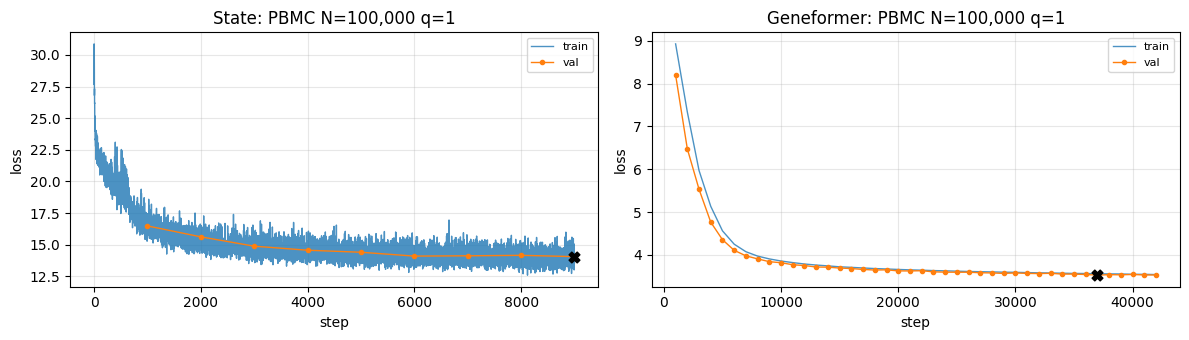

In [8]:
# One sanity plot per algorithm to confirm curves round-trip.
import matplotlib.pyplot as plt

def _sample_curve(algo):
    for ds in ['PBMC', 'larry', 'merfish', 'shendure']:
        size_map = curves.get(algo, {}).get(ds, {})
        if not size_map:
            continue
        size = sorted(size_map)[-1]
        q = sorted(size_map[size])[-1]
        return ds, size, q, size_map[size][q]
    return None

fig, axes = plt.subplots(1, len(ALGOS_WITH_CURVES), figsize=(6 * len(ALGOS_WITH_CURVES), 3.5))
for ax, algo in zip(np.atleast_1d(axes), ALGOS_WITH_CURVES):
    sample = _sample_curve(algo)
    if sample is None:
        ax.text(0.5, 0.5, f'no {algo} curves', ha='center', va='center', transform=ax.transAxes)
        continue
    ds, size, q, info = sample
    ax.plot(info['train']['step'], info['train']['loss'], label='train', alpha=0.8, lw=1)
    ax.plot(info['val']['step'],   info['val']['loss'],   label='val',   marker='o', markersize=3, lw=1)
    if info.get('best_step') is not None:
        ax.scatter([info['best_step']], [info['best_val']], marker='X', color='k', s=60, zorder=5)
    ax.set_title(f'{algo}: {ds} N={size:,} q={q:g}')
    ax.set_xlabel('step'); ax.set_ylabel('loss'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [9]:
# Round-trip check: re-open each output and show a couple of rows.
print('mi_per_run.csv');              display(pd.read_csv(CSV_DIR / 'mi_per_run.csv').head(3))
print('training_metrics_per_run.csv'); display(pd.read_csv(CSV_DIR / 'training_metrics_per_run.csv').head(3))
print('loss_curves_long.parquet');    display(pd.read_parquet(CSV_DIR / 'loss_curves_long.parquet').head(3))

print('loss_curves.h5 — listing top-level groups:')
with h5py.File(CSV_DIR / 'loss_curves.h5', 'r') as f:
    def _first_leaf(obj, path=''):
        for k in obj:
            sub = obj[k]
            if isinstance(sub, h5py.Group):
                # recurse until we find a group with datasets
                if any(isinstance(v, h5py.Dataset) for v in sub.values()):
                    return f'{path}/{k}'
                r = _first_leaf(sub, f'{path}/{k}')
                if r:
                    return r
        return None
    leaf = _first_leaf(f).lstrip('/')
    g = f[leaf]
    print(f'  example group: {leaf}')
    print(f'  datasets:      {list(g.keys())}')
    print(f'  attrs:         {dict(g.attrs)}')

mi_per_run.csv


,dataset,size,quality,algorithm,signal,seed,mi_nats
0,PBMC,100,0.001235,Geneformer,celltype.l3,42,0.40001
1,PBMC,100,0.001235,Geneformer,celltype.l3,1404,0.40144
2,PBMC,100,0.001235,Geneformer,celltype.l3,2303,0.49980


training_metrics_per_run.csv


,dataset,size,quality,algorithm,metric,value
0,PBMC,100,0.001235,Geneformer,best_step,1000.000000
1,PBMC,100,0.001235,Geneformer,best_val_loss,7.035635
2,PBMC,100,0.001235,Geneformer,epoch_max,3000.000000


loss_curves_long.parquet


,dataset,size,quality,algorithm,phase,step,loss
0,PBMC,100,0.001235,State,train,0,22.635033
1,PBMC,100,0.001235,State,train,1,25.249701
2,PBMC,100,0.001235,State,train,2,22.539207


loss_curves.h5 — listing top-level groups:
  example group: Geneformer/PBMC/100/0.0012346
  datasets:      ['train_loss', 'train_step', 'val_loss', 'val_step']
  attrs:         {'best_step': 1000, 'best_val': 7.035634517669678, 'epoch_max': 3000, 'total_steps': 6000}
